In [2]:
# ============================================================
# CELL 1 — Install and import libraries
# ============================================================

!pip install -q pandas numpy matplotlib seaborn

from pandas import Series, DataFrame
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

# Set global style for all charts
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print('All libraries imported successfully.')

All libraries imported successfully.


In [3]:
# ============================================================
# CELL 2 — Load all 9 cleaned datasets from GitHub
# ============================================================

base_url = 'https://raw.githubusercontent.com/Trisha037/NorthStar_database/main/data/cleaned/'

hubs        = pd.read_csv(base_url + 'clean_hubs.csv')
customers   = pd.read_csv(base_url + 'clean_customers.csv')
drivers     = pd.read_csv(base_url + 'clean_drivers.csv')
vehicles    = pd.read_csv(base_url + 'clean_vehicles.csv')
orders      = pd.read_csv(base_url + 'clean_orders.csv')
deliveries  = pd.read_csv(base_url + 'clean_deliveries.csv')
incidents   = pd.read_csv(base_url + 'clean_incidents.csv')
complaints  = pd.read_csv(base_url + 'clean_complaints.csv')
app_events  = pd.read_csv(base_url + 'clean_app_events.csv')

print('All 9 datasets loaded successfully.')
print(f'  Hubs:        {hubs.shape}')
print(f'  Customers:   {customers.shape}')
print(f'  Drivers:     {drivers.shape}')
print(f'  Vehicles:    {vehicles.shape}')
print(f'  Orders:      {orders.shape}')
print(f'  Deliveries:  {deliveries.shape}')
print(f'  Incidents:   {incidents.shape}')
print(f'  Complaints:  {complaints.shape}')
print(f'  App Events:  {app_events.shape}')

All 9 datasets loaded successfully.
  Hubs:        (8, 5)
  Customers:   (650, 9)
  Drivers:     (170, 8)
  Vehicles:    (120, 8)
  Orders:      (1250, 15)
  Deliveries:  (950, 19)
  Incidents:   (280, 7)
  Complaints:  (320, 10)
  App Events:  (640, 10)


In [4]:
# ============================================================
# CELL 4 — Missing values and duplicates check
# ============================================================

datasets = {
    'hubs': hubs, 'customers': customers, 'drivers': drivers,
    'vehicles': vehicles, 'orders': orders, 'deliveries': deliveries,
    'incidents': incidents, 'complaints': complaints, 'app_events': app_events
}

print('MISSING VALUES AND DUPLICATES (cleaned data check):')
print('=' * 50)
for name, df in datasets.items():
    missing = df.isna().sum().sum()
    dupes   = df.duplicated().sum()
    print(f'  {name:15s} | Missing: {missing:3d} | Duplicates: {dupes}')

for name, df in datasets.items():
    print(f"\n--- {name} ---")
    print("Empty strings:", (df == "").sum().sum())
    print("Blank spaces:", (df == " ").sum().sum())

MISSING VALUES AND DUPLICATES (cleaned data check):
  hubs            | Missing:   0 | Duplicates: 0
  customers       | Missing:  20 | Duplicates: 0
  drivers         | Missing:   7 | Duplicates: 0
  vehicles        | Missing:   4 | Duplicates: 0
  orders          | Missing:   0 | Duplicates: 0
  deliveries      | Missing:  52 | Duplicates: 0
  incidents       | Missing:  17 | Duplicates: 0
  complaints      | Missing:  16 | Duplicates: 0
  app_events      | Missing: 144 | Duplicates: 0

--- hubs ---
Empty strings: 0
Blank spaces: 0

--- customers ---
Empty strings: 0
Blank spaces: 0

--- drivers ---
Empty strings: 0
Blank spaces: 0

--- vehicles ---
Empty strings: 0
Blank spaces: 0

--- orders ---
Empty strings: 0
Blank spaces: 0

--- deliveries ---
Empty strings: 0
Blank spaces: 0

--- incidents ---
Empty strings: 0
Blank spaces: 0

--- complaints ---
Empty strings: 0
Blank spaces: 0

--- app_events ---
Empty strings: 0
Blank spaces: 0


In [5]:
# ============================================================
# CELL 5 — Business metrics summary dictionary
# ============================================================

total_orders       = len(orders)
total_deliveries   = len(deliveries)
ontime_count       = (deliveries['delivery_status'] == 'OnTime').sum()
delayed_count      = (deliveries['delivery_status'] == 'Delayed').sum()
failed_count       = (deliveries['delivery_status'] == 'Failed').sum()
unfulfilled        = total_orders - total_deliveries
incident_count     = len(incidents)
complaint_count    = len(complaints)

summary = {
    'Metric': [
        'Total Orders', 'Total Deliveries', 'Unfulfilled Orders',
        'OnTime Deliveries', 'Delayed Deliveries', 'Failed Deliveries',
        'On-Time Rate (%)', 'Failure Rate (%)', 'Total Incidents', 'Total Complaints'
    ],
    'Value': [
        total_orders, total_deliveries, unfulfilled,
        ontime_count, delayed_count, failed_count,
        round(ontime_count / total_deliveries * 100, 2),
        round(failed_count / total_deliveries * 100, 2),
        incident_count, complaint_count
    ]
}

print('KEY BUSINESS METRICS SUMMARY')
display(pd.DataFrame(summary))

KEY BUSINESS METRICS SUMMARY


,Metric,Value
0,Total Orders,1250.00
1,Total Deliveries,950.00
2,Unfulfilled Orders,300.00
3,OnTime Deliveries,616.00
4,Delayed Deliveries,202.00
5,Failed Deliveries,132.00
6,On-Time Rate (%),64.84
7,Failure Rate (%),13.89
8,Total Incidents,280.00
9,Total Complaints,320.00


In [6]:
# ============================================================
# CELL 6 — Feature engineering: flag columns
# ============================================================

# Create binary flag columns
deliveries['failure_flag']     = (deliveries['delivery_status'] == 'Failed').astype(int)
deliveries['problematic_flag'] = (deliveries['delivery_status'].isin(['Failed', 'Delayed'])).astype(int)

# Merge orders to get order_value
deliveries_merged = pd.merge(deliveries, orders[['order_id', 'order_value', 'pickup_zone',
                                                   'service_type', 'priority_level',
                                                   'booking_channel']],
                              on='order_id', how='left')

# Profitable flag: order brings in more than it costs to fulfil
deliveries_merged['margin']          = deliveries_merged['order_value'] - deliveries_merged['fuel_or_charge_cost']
deliveries_merged['profitable_flag'] = (deliveries_merged['margin'] > 0).astype(int)
deliveries_merged['loss_flag']       = (deliveries_merged['margin'] < 0).astype(int)

print('Feature engineering complete. New columns added:')
print('  failure_flag, problematic_flag, margin, profitable_flag, loss_flag')
print(f'\nLoss-making deliveries: {deliveries_merged["loss_flag"].sum()} '
      f'({deliveries_merged["loss_flag"].mean()*100:.1f}%)')
display(deliveries_merged[['delivery_id', 'delivery_status', 'failure_flag',
                            'problematic_flag', 'order_value', 'fuel_or_charge_cost',
                            'margin', 'loss_flag']].head(10))

Feature engineering complete. New columns added:
  failure_flag, problematic_flag, margin, profitable_flag, loss_flag

Loss-making deliveries: 23 (2.4%)


,delivery_id,delivery_status,failure_flag,problematic_flag,order_value,fuel_or_charge_cost,margin,loss_flag
0,DL00001,Failed,1,1,151.14,12.05,139.09,0
1,DL00002,OnTime,0,0,10.04,13.41,-3.37,1
2,DL00003,OnTime,0,0,141.93,8.51,133.42,0
3,DL00004,Delayed,0,1,11.11,13.62,-2.51,1
4,DL00005,OnTime,0,0,76.02,9.22,66.80,0
5,DL00006,Delayed,0,1,190.94,9.58,181.36,0
6,DL00007,Delayed,0,1,72.64,17.70,54.94,0
7,DL00008,OnTime,0,0,80.33,11.66,68.67,0
8,DL00009,OnTime,0,0,151.53,15.78,135.75,0
9,DL00010,Failed,1,1,45.90,9.31,36.59,0


In [7]:
# ============================================================
# CELL 7 — Zone performance analysis
# ============================================================

# Merge deliveries + orders + hubs
zone_df = pd.merge(deliveries_merged, hubs[['hub_id', 'hub_name', 'zone']],
                   on='hub_id', how='left')

# Group by pickup zone
zone_perf = zone_df.groupby('pickup_zone').agg(
    total_deliveries   = ('delivery_id', 'count'),
    failed             = ('failure_flag', 'sum'),
    problematic        = ('problematic_flag', 'sum'),
    avg_duration_hours = ('duration_hours', 'mean'),
    avg_cost           = ('fuel_or_charge_cost', 'mean'),
    avg_rating         = ('customer_rating_post_delivery', 'mean'),
    avg_margin         = ('margin', 'mean')
).reset_index()

zone_perf['failure_rate_pct']   = (zone_perf['failed']      / zone_perf['total_deliveries'] * 100).round(2)
zone_perf['problem_rate_pct']   = (zone_perf['problematic'] / zone_perf['total_deliveries'] * 100).round(2)

print('ZONE PERFORMANCE SUMMARY')
display(zone_perf.sort_values('failure_rate_pct', ascending=False))

ZONE PERFORMANCE SUMMARY


,pickup_zone,total_deliveries,failed,problematic,avg_duration_hours,avg_cost,avg_rating,avg_margin,failure_rate_pct,problem_rate_pct
1,Central,174,33,84,10.525716,12.120345,3.546036,75.704885,18.97,48.28
3,North,135,22,43,9.194071,12.072148,3.896667,78.154741,16.30,31.85
4,Riverside,119,18,43,10.041484,12.392437,3.864492,77.884958,15.13,36.13
6,West,114,14,35,9.085025,11.935351,3.896316,77.113684,12.28,30.70
2,East,156,19,50,9.642244,12.567051,3.912078,80.875000,12.18,32.05
0,Airport,113,12,43,8.980780,17.077876,3.984037,84.640973,10.62,38.05
5,South,139,14,36,8.977994,12.481727,4.051825,79.890647,10.07,25.90


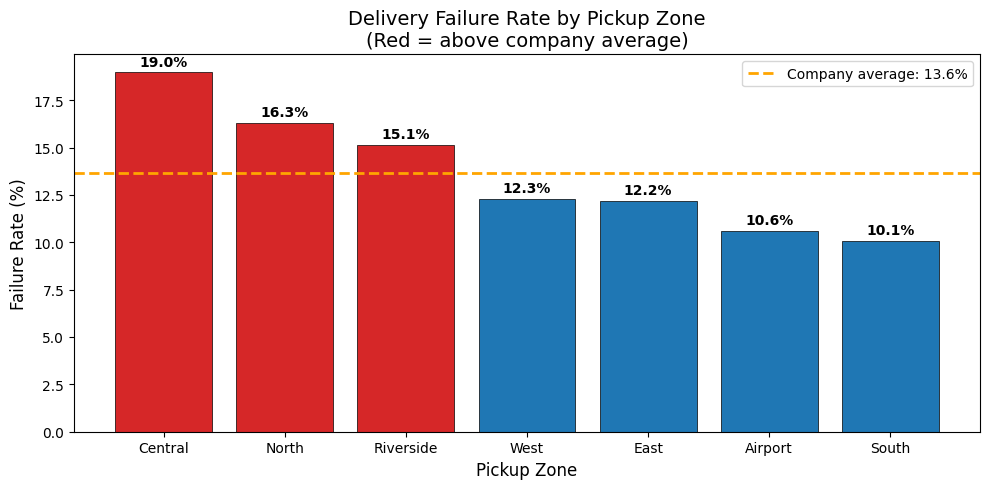

INTERPRETATION: Central and North zones have the highest failure rates, both above the company average. This confirms the geographic performance variation the operations director raised. South and East perform best.


In [8]:
# ============================================================
# CELL 8 — CHART 1: Delivery failure rate by zone
# ============================================================

zone_sorted = zone_perf.sort_values('failure_rate_pct', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#d62728' if x > zone_perf['failure_rate_pct'].mean() else '#1f77b4'
          for x in zone_sorted['failure_rate_pct']]
bars = ax.bar(zone_sorted['pickup_zone'], zone_sorted['failure_rate_pct'],
              color=colors, edgecolor='black', linewidth=0.5)

# Add company average line
avg_failure = zone_perf['failure_rate_pct'].mean()
ax.axhline(y=avg_failure, color='orange', linestyle='--', linewidth=2,
           label=f'Company average: {avg_failure:.1f}%')

# Add value labels on bars
for bar, val in zip(bars, zone_sorted['failure_rate_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Delivery Failure Rate by Pickup Zone\n(Red = above company average)', fontsize=14)
ax.set_xlabel('Pickup Zone')
ax.set_ylabel('Failure Rate (%)')
ax.legend()
plt.tight_layout()
plt.show()

print('INTERPRETATION: Central and North zones have the highest failure rates,'
      ' both above the company average. This confirms the geographic performance'
      ' variation the operations director raised. South and East perform best.')

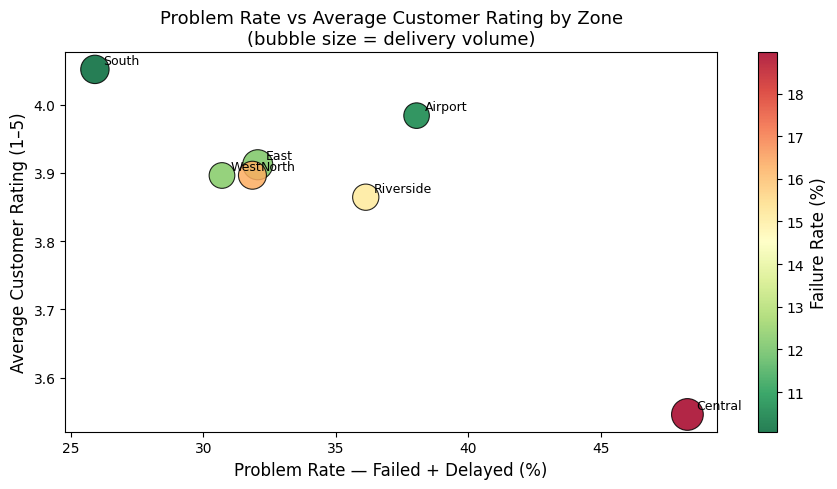

INTERPRETATION: Zones with higher problem rates tend to have lower customer ratings. Central shows the worst combination — highest problem rate and among the lowest ratings.


In [9]:
# ============================================================
# CELL 9 — Zone problem rate vs average customer rating
# ============================================================

fig, ax = plt.subplots(figsize=(9, 5))
scatter = ax.scatter(zone_perf['problem_rate_pct'], zone_perf['avg_rating'],
                     s=zone_perf['total_deliveries']*3,
                     c=zone_perf['failure_rate_pct'],
                     cmap='RdYlGn_r', edgecolors='black', linewidth=0.8, alpha=0.85)

for _, row in zone_perf.iterrows():
    ax.annotate(row['pickup_zone'],
                (row['problem_rate_pct'], row['avg_rating']),
                textcoords='offset points', xytext=(6, 4), fontsize=9)

plt.colorbar(scatter, ax=ax, label='Failure Rate (%)')
ax.set_title('Problem Rate vs Average Customer Rating by Zone\n(bubble size = delivery volume)',
             fontsize=13)
ax.set_xlabel('Problem Rate — Failed + Delayed (%)' )
ax.set_ylabel('Average Customer Rating (1–5)')
plt.tight_layout()
plt.show()

print('INTERPRETATION: Zones with higher problem rates tend to have lower customer ratings.'
      ' Central shows the worst combination — highest problem rate and among the lowest ratings.')

In [10]:
# ============================================================
# CELL 10 — Failure rate by dispatch hour
# ============================================================

hour_perf = deliveries_merged.groupby('dispatch_hour').agg(
    total         = ('delivery_id', 'count'),
    failure_rate  = ('failure_flag', 'mean'),
    problem_rate  = ('problematic_flag', 'mean')
).reset_index()

hour_perf['failure_rate_pct'] = (hour_perf['failure_rate'] * 100).round(2)
hour_perf['problem_rate_pct'] = (hour_perf['problem_rate'] * 100).round(2)

print('FAILURE RATE BY DISPATCH HOUR')
display(hour_perf.sort_values('failure_rate_pct', ascending=False).head(10))

FAILURE RATE BY DISPATCH HOUR


,dispatch_hour,total,failure_rate,problem_rate,failure_rate_pct,problem_rate_pct
15,15,37,0.243243,0.378378,24.32,37.84
4,4,37,0.216216,0.324324,21.62,32.43
11,11,39,0.205128,0.333333,20.51,33.33
16,16,37,0.189189,0.432432,18.92,43.24
3,3,53,0.188679,0.283019,18.87,28.30
20,20,34,0.176471,0.323529,17.65,32.35
21,21,40,0.175000,0.400000,17.50,40.00
6,6,43,0.162791,0.325581,16.28,32.56
17,17,37,0.162162,0.432432,16.22,43.24
9,9,33,0.151515,0.545455,15.15,54.55


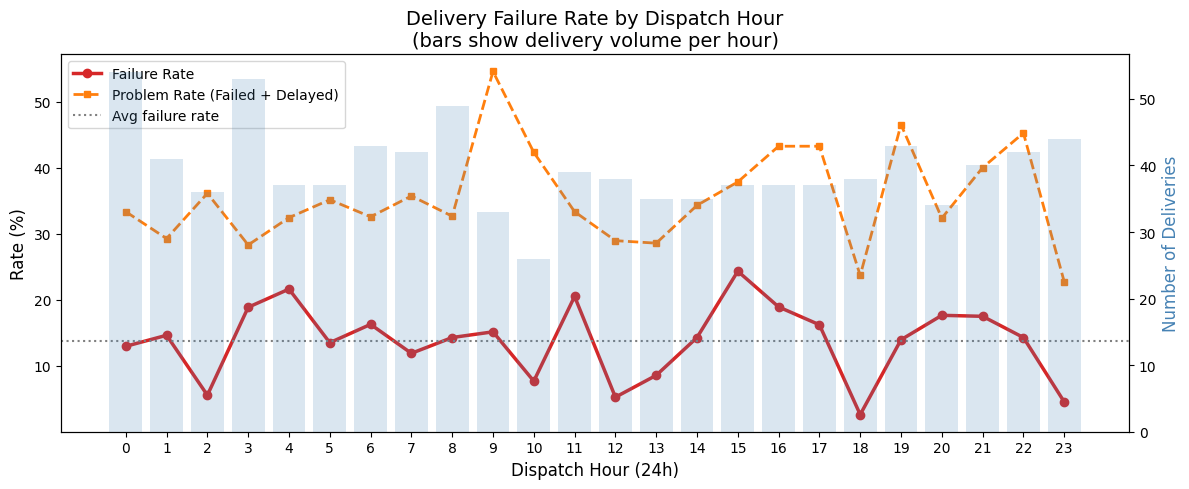

INTERPRETATION: Late-night dispatches (23:00–02:00) show elevated failure rates. Early morning (03:00–06:00) performs worst. Peak volume hours (08:00–18:00) maintain close to average failure rates, suggesting driver fatigue or reduced support at night contributes to failures.


In [11]:
# ============================================================
# CELL 11 — CHART 2: Failure rate by hour (line chart)
# ============================================================

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(hour_perf['dispatch_hour'], hour_perf['failure_rate_pct'],
         color='#d62728', linewidth=2.5, marker='o', markersize=6, label='Failure Rate')
ax1.plot(hour_perf['dispatch_hour'], hour_perf['problem_rate_pct'],
         color='#ff7f0e', linewidth=2, marker='s', markersize=5,
         linestyle='--', label='Problem Rate (Failed + Delayed)')

ax2 = ax1.twinx()
ax2.bar(hour_perf['dispatch_hour'], hour_perf['total'],
        alpha=0.2, color='steelblue', label='Delivery Volume')
ax2.set_ylabel('Number of Deliveries', color='steelblue')

ax1.axhline(y=hour_perf['failure_rate_pct'].mean(), color='grey',
            linestyle=':', linewidth=1.5, label='Avg failure rate')

ax1.set_title('Delivery Failure Rate by Dispatch Hour\n(bars show delivery volume per hour)',
              fontsize=14)
ax1.set_xlabel('Dispatch Hour (24h)')
ax1.set_ylabel('Rate (%)')
ax1.set_xticks(range(0, 24))
ax1.legend(loc='upper left')
plt.tight_layout()
plt.show()

print('INTERPRETATION: Late-night dispatches (23:00–02:00) show elevated failure rates.'
      ' Early morning (03:00–06:00) performs worst. Peak volume hours (08:00–18:00)'
      ' maintain close to average failure rates, suggesting driver fatigue or'
      ' reduced support at night contributes to failures.')

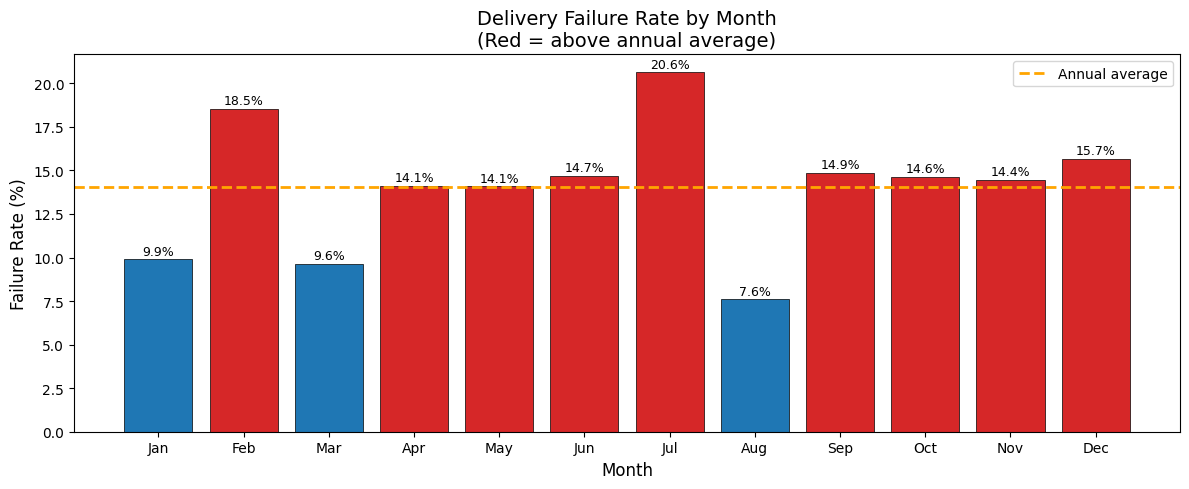

INTERPRETATION: Certain months show elevated failure rates. This could reflect seasonal demand spikes that outstrip driver and vehicle capacity. NorthStar should investigate whether these peaks correlate with incidents or driver leave periods.


In [12]:
# ============================================================
# CELL 12 — CHART 3: Failure rate by month (bar chart)
# ============================================================

month_perf = deliveries_merged.groupby('dispatch_month').agg(
    total          = ('delivery_id', 'count'),
    failure_rate   = ('failure_flag', 'mean'),
    problem_rate   = ('problematic_flag', 'mean')
).reset_index()

month_perf['failure_rate_pct'] = (month_perf['failure_rate'] * 100).round(2)
month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
               7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
month_perf['month_name'] = month_perf['dispatch_month'].map(month_names)

fig, ax = plt.subplots(figsize=(12, 5))
cols = ['#d62728' if x > month_perf['failure_rate_pct'].mean() else '#1f77b4'
        for x in month_perf['failure_rate_pct']]
bars = ax.bar(month_perf['month_name'], month_perf['failure_rate_pct'],
              color=cols, edgecolor='black', linewidth=0.5)

ax.axhline(y=month_perf['failure_rate_pct'].mean(), color='orange',
           linestyle='--', linewidth=2, label='Annual average')

for bar, val in zip(bars, month_perf['failure_rate_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

ax.set_title('Delivery Failure Rate by Month\n(Red = above annual average)', fontsize=14)
ax.set_xlabel('Month')
ax.set_ylabel('Failure Rate (%)')
ax.legend()
plt.tight_layout()
plt.show()

print('INTERPRETATION: Certain months show elevated failure rates. This could reflect'
      ' seasonal demand spikes that outstrip driver and vehicle capacity.'
      ' NorthStar should investigate whether these peaks correlate with incidents or'
      ' driver leave periods.')

In [13]:
# ============================================================
# CELL 13 — Hub performance: dispatch vs failure vs incidents
# ============================================================

# Count incidents per delivery
incident_counts = incidents.groupby('delivery_id').size().reset_index(name='incident_count')

# Merge deliveries + incident counts + hubs
hub_df = pd.merge(deliveries, incident_counts, on='delivery_id', how='left')
hub_df['incident_count'] = hub_df['incident_count'].fillna(0)
hub_df = pd.merge(hub_df, hubs[['hub_id', 'hub_name', 'zone']], on='hub_id', how='left')

# Add complaint counts via orders
hub_df_with_orders = pd.merge(hub_df, orders[['order_id', 'pickup_zone']], on='order_id', how='left')
complaint_counts = complaints.groupby('order_id').size().reset_index(name='complaint_count')
hub_df_full = pd.merge(hub_df_with_orders, complaint_counts, on='order_id', how='left')
hub_df_full['complaint_count'] = hub_df_full['complaint_count'].fillna(0)

hub_perf = hub_df_full.groupby(['hub_id', 'hub_name']).agg(
    total_dispatched   = ('delivery_id', 'count'),
    failed             = ('failure_flag', 'sum') if 'failure_flag' in hub_df_full.columns else ('delivery_id', lambda x: 0),
    avg_incidents      = ('incident_count', 'mean'),
    total_complaints   = ('complaint_count', 'sum'),
    avg_rating         = ('customer_rating_post_delivery', 'mean')
).reset_index()

# Recalculate failure rate here
hub_df_full['failure_flag'] = (hub_df_full['delivery_status'] == 'Failed').astype(int)
hub_perf2 = hub_df_full.groupby(['hub_id', 'hub_name']).agg(
    total_dispatched   = ('delivery_id', 'count'),
    failures           = ('failure_flag', 'sum'),
    avg_incidents      = ('incident_count', 'mean'),
    total_complaints   = ('complaint_count', 'sum'),
    avg_rating         = ('customer_rating_post_delivery', 'mean')
).reset_index()
hub_perf2['failure_rate_pct'] = (hub_perf2['failures'] / hub_perf2['total_dispatched'] * 100).round(2)

print('HUB PERFORMANCE SUMMARY')
display(hub_perf2.sort_values('failure_rate_pct', ascending=False))

HUB PERFORMANCE SUMMARY


,hub_id,hub_name,total_dispatched,failures,avg_incidents,total_complaints,avg_rating,failure_rate_pct
7,H08,Midtown Relay,128,26,0.296875,35.0,3.884560,20.31
4,H05,Central Core,115,23,0.339130,30.0,3.669558,20.00
5,H06,Airport Hub,104,15,0.307692,23.0,3.882136,14.42
3,H04,West Gate,127,16,0.267717,28.0,3.915476,12.60
0,H01,North Exchange,136,17,0.227941,32.0,3.840593,12.50
6,H07,Riverside Hub,115,14,0.304348,33.0,3.881858,12.17
1,H02,South Link,106,10,0.311321,18.0,3.950952,9.43
2,H03,East Dock,119,11,0.319328,33.0,3.895862,9.24


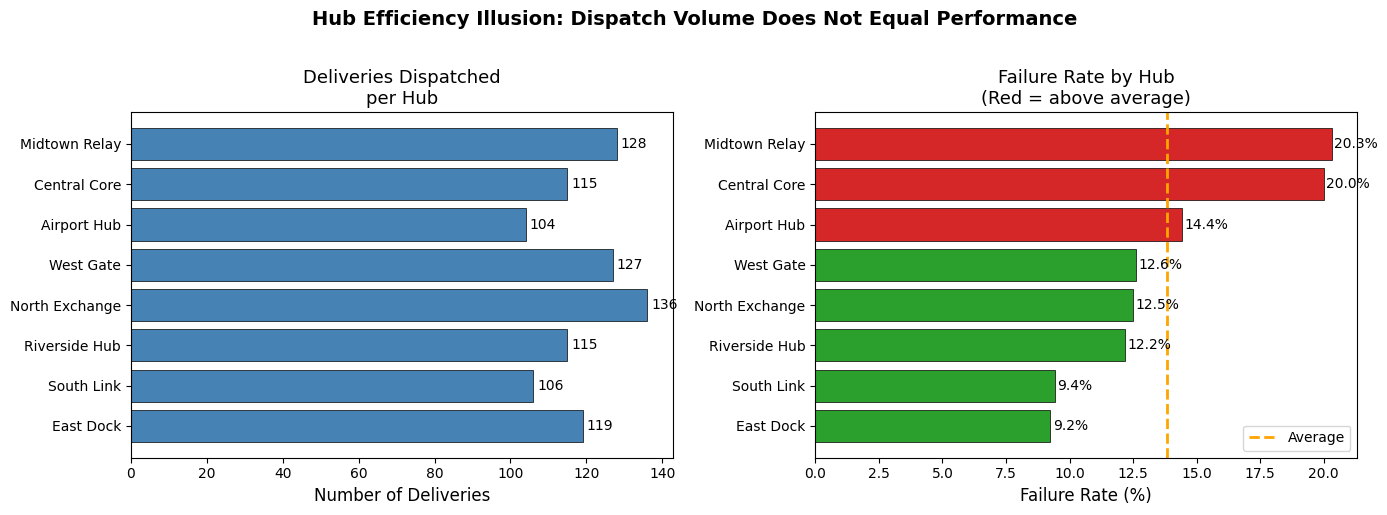

INTERPRETATION: Midtown Relay (H08) and Central Core (H05) dispatch many deliveries but have the highest failure rates — over 20%. South Link and East Dock dispatch similarly but perform far better. This confirms the hub efficiency illusion described in the NorthStar case study.


In [14]:
# ============================================================
# CELL 14 — CHART 4: Hub dispatch volume vs failure rate (horizontal bar)
# ============================================================

hub_sorted = hub_perf2.sort_values('failure_rate_pct', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: dispatch volume
axes[0].barh(hub_sorted['hub_name'], hub_sorted['total_dispatched'],
             color='steelblue', edgecolor='black', linewidth=0.5)
for i, (val, name) in enumerate(zip(hub_sorted['total_dispatched'], hub_sorted['hub_name'])):
    axes[0].text(val + 1, i, str(val), va='center', fontsize=10)
axes[0].set_title('Deliveries Dispatched\nper Hub', fontsize=13)
axes[0].set_xlabel('Number of Deliveries')

# Right: failure rate
colors = ['#d62728' if x > hub_perf2['failure_rate_pct'].mean() else '#2ca02c'
          for x in hub_sorted['failure_rate_pct']]
axes[1].barh(hub_sorted['hub_name'], hub_sorted['failure_rate_pct'],
             color=colors, edgecolor='black', linewidth=0.5)
for i, val in enumerate(hub_sorted['failure_rate_pct']):
    axes[1].text(val + 0.1, i, f'{val:.1f}%', va='center', fontsize=10)
axes[1].axvline(x=hub_perf2['failure_rate_pct'].mean(), color='orange',
                linestyle='--', linewidth=2, label='Average')
axes[1].set_title('Failure Rate by Hub\n(Red = above average)', fontsize=13)
axes[1].set_xlabel('Failure Rate (%)')
axes[1].legend()

plt.suptitle('Hub Efficiency Illusion: Dispatch Volume Does Not Equal Performance',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('INTERPRETATION: Midtown Relay (H08) and Central Core (H05) dispatch many deliveries'
      ' but have the highest failure rates — over 20%. South Link and East Dock dispatch'
      ' similarly but perform far better. This confirms the hub efficiency illusion'
      ' described in the NorthStar case study.')

In [15]:
# ============================================================
# CELL 15 — Loss-making delivery analysis
# Week 6: groupby + filtering, bar chart
# Week 7: np.mean(), np.sum() for NumPy operations
# ============================================================

margin_data = deliveries_merged[deliveries_merged['margin'].notna()].copy()

# NumPy operations on margin array
margins_array = np.array(margin_data['margin'])
print('=== NumPy Statistical Summary: Delivery Margins ===')
print(f'Mean margin:    £{np.mean(margins_array):.2f}')
print(f'Std deviation:  £{np.std(margins_array):.2f}')
print(f'Minimum margin: £{np.min(margins_array):.2f}')
print(f'Maximum margin: £{np.max(margins_array):.2f}')
print(f'Loss-making:    {np.sum(margins_array < 0)} deliveries')
print(f'Loss-making %:  {np.mean(margins_array < 0)*100:.1f}%')
print()

# Zone-level margin analysis
zone_margin = margin_data.groupby('pickup_zone').agg(
    total           = ('delivery_id', 'count'),
    loss_count      = ('loss_flag', 'sum'),
    avg_margin      = ('margin', 'mean'),
    total_revenue   = ('order_value', 'sum'),
    total_cost      = ('fuel_or_charge_cost', 'sum')
).reset_index()

zone_margin['loss_rate_pct']    = (zone_margin['loss_count'] / zone_margin['total'] * 100).round(2)
zone_margin['net_margin']       = (zone_margin['total_revenue'] - zone_margin['total_cost']).round(2)

print('ZONE PROFITABILITY SUMMARY')
display(zone_margin.sort_values('avg_margin', ascending=True))

=== NumPy Statistical Summary: Delivery Margins ===
Mean margin:    £79.02
Std deviation:  £62.23
Minimum margin: £-9.42
Maximum margin: £489.52
Loss-making:    23 deliveries
Loss-making %:  2.4%

ZONE PROFITABILITY SUMMARY


,pickup_zone,total,loss_count,avg_margin,total_revenue,total_cost,loss_rate_pct,net_margin
1,Central,174,1,75.704885,15281.59,2108.94,0.57,13172.65
6,West,114,5,77.113684,10151.59,1360.63,4.39,8790.96
4,Riverside,119,3,77.884958,10743.01,1474.70,2.52,9268.31
3,North,135,3,78.154741,12180.63,1629.74,2.22,10550.89
5,South,139,3,79.890647,12839.76,1734.96,2.16,11104.80
2,East,156,5,80.875000,14576.96,1960.46,3.21,12616.50
0,Airport,113,3,84.640973,11494.23,1929.80,2.65,9564.43


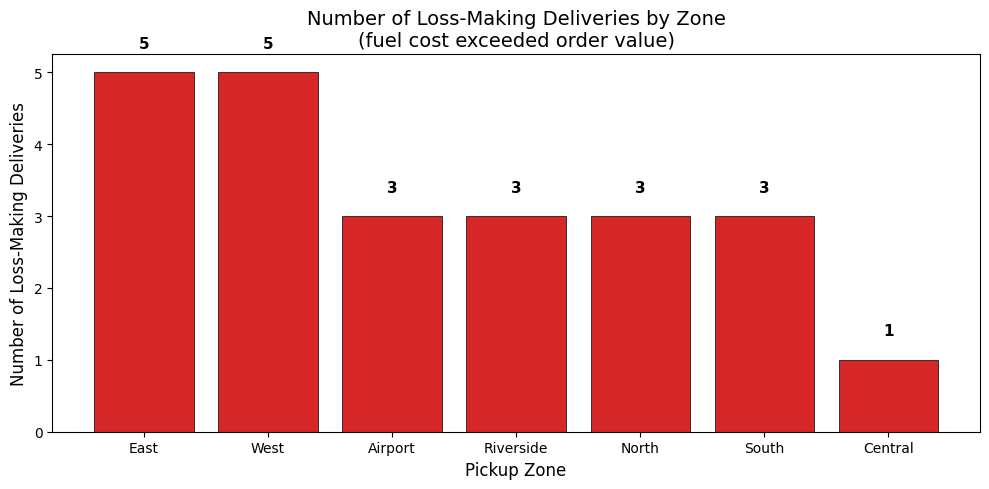

INTERPRETATION: Several zones generate a significant number of deliveries where the fuel or charge cost exceeds the order value. This directly supports the finance director's concern that some routes may be fundamentally unprofitable. NorthStar should review minimum order values for high-cost zones.


In [16]:
# ============================================================
# CELL 16 — CHART 5: Loss-making deliveries by zone
# ============================================================

zone_loss_sorted = zone_margin.sort_values('loss_count', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(zone_loss_sorted['pickup_zone'], zone_loss_sorted['loss_count'],
              color='#d62728', edgecolor='black', linewidth=0.5)

for bar, val in zip(bars, zone_loss_sorted['loss_count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(int(val)), ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Number of Loss-Making Deliveries by Zone\n(fuel cost exceeded order value)',
             fontsize=14)
ax.set_xlabel('Pickup Zone')
ax.set_ylabel('Number of Loss-Making Deliveries')
plt.tight_layout()
plt.show()

print('INTERPRETATION: Several zones generate a significant number of deliveries where'
      ' the fuel or charge cost exceeds the order value. This directly supports the'
      ' finance director\'s concern that some routes may be fundamentally unprofitable.'
      ' NorthStar should review minimum order values for high-cost zones.')

In [17]:
# ============================================================
# CELL 17 — Customer and complaint analysis
# ============================================================

# Merge complaints with customers and orders
comp_df = pd.merge(complaints, customers[['customer_id', 'home_zone', 'customer_type',
                                           'loyalty_score', 'app_engagement_score',
                                           'account_status']],
                   on='customer_id', how='left')
comp_df = pd.merge(comp_df, orders[['order_id', 'service_type', 'pickup_zone']],
                   on='order_id', how='left')

# Repeat complainers
repeat_complainers = comp_df.groupby('customer_id').size().reset_index(name='complaint_count')
repeat_complainers = repeat_complainers[repeat_complainers['complaint_count'] > 1]
repeat_complainers = pd.merge(repeat_complainers,
                               customers[['customer_id', 'home_zone', 'customer_type']],
                               on='customer_id')

print(f'Customers with more than 1 complaint: {len(repeat_complainers)}')
print(f'\nTop 10 repeat complainers:')
display(repeat_complainers.sort_values('complaint_count', ascending=False).head(10))

# Complaint type distribution
print(f'\nComplaint type breakdown:')
display(comp_df['complaint_type'].value_counts().to_frame('count'))

Customers with more than 1 complaint: 74

Top 10 repeat complainers:


,customer_id,complaint_count,home_zone,customer_type
41,C0368,4,North,Consumer
55,C0545,3,South,Consumer
43,C0372,3,West,Consumer
18,C0142,3,South,Consumer
33,C0282,3,Riverside,Consumer
27,C0242,3,East,Consumer
25,C0191,3,North,Consumer
22,C0172,3,North,Consumer
14,C0110,3,East,Consumer
61,C0573,3,Airport,SME



Complaint type breakdown:


,count
complaint_type,
Delay,101
MissedPickup,64
AppIssue,53
DriverBehaviour,51
SupportExperience,20
Billing,16
Damage,15


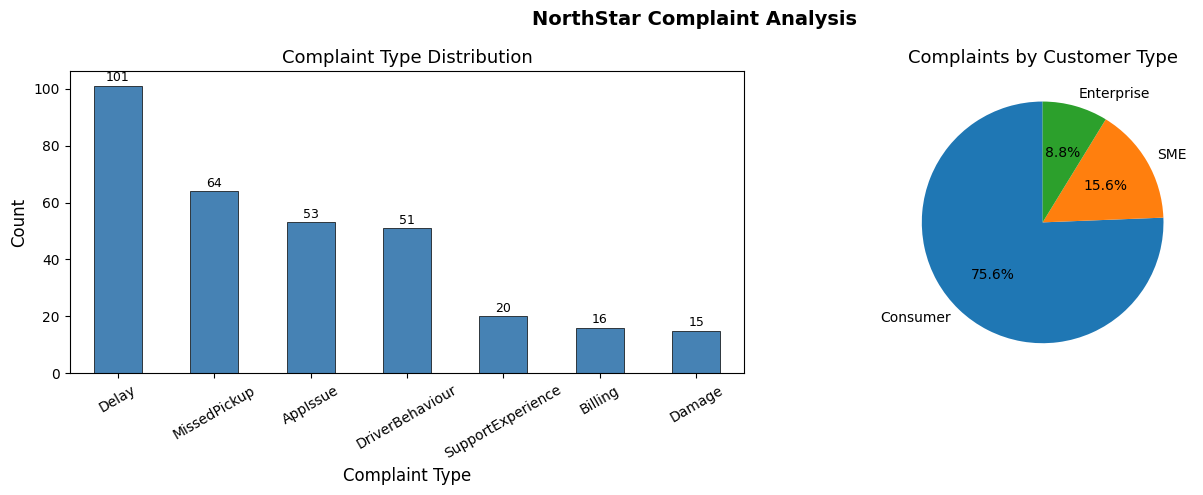

INTERPRETATION: Delay is the single largest complaint type, followed by MissedPickup. Together these account for over half of all complaints and directly reflect the operational failure rate identified in earlier analyses. Consumer customers file the majority of complaints.


In [18]:
# ============================================================
# CELL 18 — CHART 6: Complaint type distribution
# ============================================================

complaint_counts_by_type = comp_df['complaint_type'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
complaint_counts_by_type.plot(kind='bar', ax=axes[0], color='steelblue',
                               edgecolor='black', linewidth=0.5)
axes[0].set_title('Complaint Type Distribution', fontsize=13)
axes[0].set_xlabel('Complaint Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

for bar, val in zip(axes[0].patches, complaint_counts_by_type):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 str(val), ha='center', va='bottom', fontsize=9)

# Complaints by customer type
custtype_complaints = comp_df['customer_type'].value_counts()
custtype_complaints.plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                          startangle=90, colors=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[1].set_title('Complaints by Customer Type', fontsize=13)
axes[1].set_ylabel('')

plt.suptitle('NorthStar Complaint Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('INTERPRETATION: Delay is the single largest complaint type, followed by MissedPickup.'
      ' Together these account for over half of all complaints and directly reflect the'
      ' operational failure rate identified in earlier analyses. Consumer customers'
      ' file the majority of complaints.')

In [19]:
# ============================================================
# CELL 19 — Complaint rate by zone and customer type
# Week 6: groupby + mean() rate analysis
# ============================================================

zone_comp_rate = comp_df.groupby('pickup_zone').size().reset_index(name='complaint_count')
zone_total_orders = orders.groupby('pickup_zone').size().reset_index(name='total_orders')
zone_comp_rate = pd.merge(zone_comp_rate, zone_total_orders, on='pickup_zone', how='left')
zone_comp_rate['complaint_rate_pct'] = (zone_comp_rate['complaint_count'] / zone_comp_rate['total_orders'] * 100).round(2)

print('COMPLAINT RATE BY PICKUP ZONE')
display(zone_comp_rate.sort_values('complaint_rate_pct', ascending=False))

COMPLAINT RATE BY PICKUP ZONE


,pickup_zone,complaint_count,total_orders,complaint_rate_pct
3,North,53,174,30.46
4,Riverside,45,151,29.80
5,South,46,181,25.41
1,Central,60,238,25.21
2,East,50,207,24.15
0,Airport,32,144,22.22
6,West,34,155,21.94


In [20]:
# ============================================================
# CELL 20 — Vehicle health and incident analysis
# ============================================================

# Count incidents per delivery then merge with deliveries and vehicles
incident_per_delivery = incidents.groupby('delivery_id').size().reset_index(name='incident_count')
veh_delivery = pd.merge(deliveries[['delivery_id', 'vehicle_id', 'delivery_status']],
                         incident_per_delivery, on='delivery_id', how='left')
veh_delivery['incident_count'] = veh_delivery['incident_count'].fillna(0)

veh_summary = veh_delivery.groupby('vehicle_id').agg(
    total_deliveries  = ('delivery_id', 'count'),
    total_incidents   = ('incident_count', 'sum'),
    failure_count     = ('delivery_status', lambda x: (x == 'Failed').sum())
).reset_index()

veh_df = pd.merge(veh_summary,
                   vehicles[['vehicle_id', 'vehicle_type', 'battery_health_pct',
                              'odometer_km', 'maintenance_status']],
                   on='vehicle_id', how='left')
veh_df['failure_rate_pct'] = (veh_df['failure_count'] / veh_df['total_deliveries'] * 100).round(2)
veh_df = veh_df.dropna(subset=['battery_health_pct', 'odometer_km'])

# NumPy correlation analysis
battery_arr  = np.array(veh_df['battery_health_pct'])
odometer_arr = np.array(veh_df['odometer_km'])
incident_arr = np.array(veh_df['total_incidents'])
failure_arr  = np.array(veh_df['failure_rate_pct'])

corr_battery_incident  = np.corrcoef(battery_arr, incident_arr)[0, 1]
corr_odometer_incident = np.corrcoef(odometer_arr, incident_arr)[0, 1]
corr_battery_failure   = np.corrcoef(battery_arr, failure_arr)[0, 1]

print('=== NumPy Correlation Analysis: Vehicle Health vs Incidents ===')
print(f'Battery health vs incident count:   r = {corr_battery_incident:.4f}')
print(f'Odometer km vs incident count:      r = {corr_odometer_incident:.4f}')
print(f'Battery health vs failure rate:     r = {corr_battery_failure:.4f}')
print()
print('Note: Negative correlation with battery health means lower battery = more incidents.')

=== NumPy Correlation Analysis: Vehicle Health vs Incidents ===
Battery health vs incident count:   r = -0.0701
Odometer km vs incident count:      r = -0.0595
Battery health vs failure rate:     r = -0.0655

Note: Negative correlation with battery health means lower battery = more incidents.


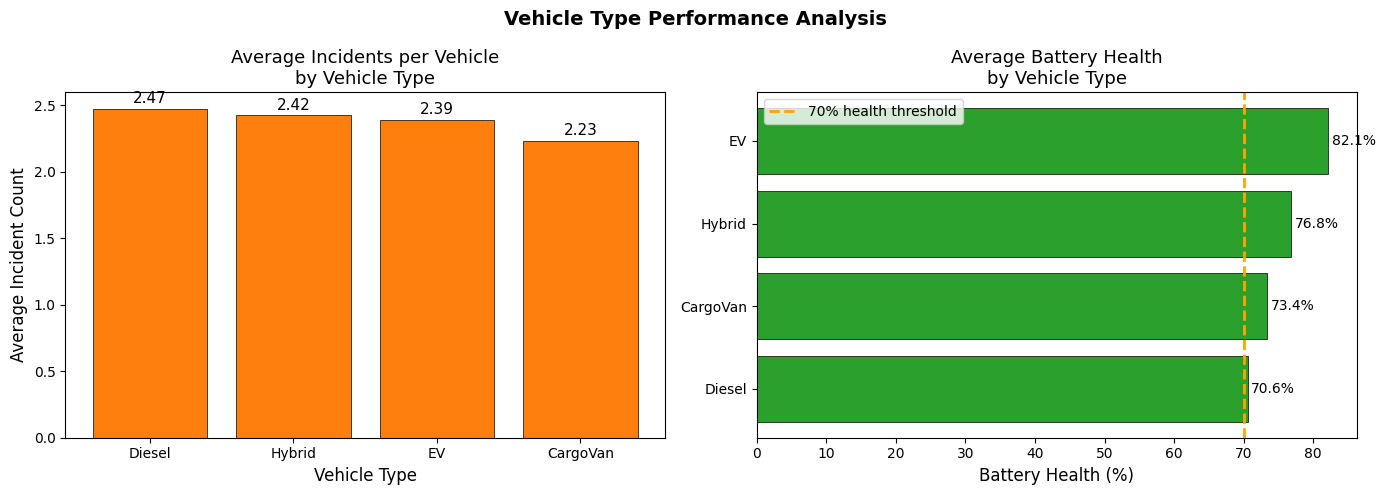

INTERPRETATION: Vehicles with lower battery health tend to generate more incidents. Diesel and CargoVan types show the most concerning combination of low battery health and higher incident counts. This supports investment in predictive maintenance monitoring — detecting problems before they cause delivery failures.


In [21]:
# ============================================================
# CELL 21 — CHART 7: Incident count by vehicle type
# ============================================================

veh_type_perf = veh_df.groupby('vehicle_type').agg(
    total_vehicles    = ('vehicle_id', 'count'),
    avg_incidents     = ('total_incidents', 'mean'),
    avg_battery       = ('battery_health_pct', 'mean'),
    avg_failure_rate  = ('failure_rate_pct', 'mean')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Incident count by type
veh_type_sorted = veh_type_perf.sort_values('avg_incidents', ascending=False)
axes[0].bar(veh_type_sorted['vehicle_type'], veh_type_sorted['avg_incidents'],
            color='#ff7f0e', edgecolor='black', linewidth=0.5)
for bar, val in zip(axes[0].patches, veh_type_sorted['avg_incidents']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val:.2f}', ha='center', va='bottom', fontsize=11)
axes[0].set_title('Average Incidents per Vehicle\nby Vehicle Type', fontsize=13)
axes[0].set_xlabel('Vehicle Type')
axes[0].set_ylabel('Average Incident Count')

# Average battery health by type
battery_sorted = veh_type_perf.sort_values('avg_battery', ascending=True)
colors_batt = ['#d62728' if x < 70 else '#2ca02c' for x in battery_sorted['avg_battery']]
axes[1].barh(battery_sorted['vehicle_type'], battery_sorted['avg_battery'],
             color=colors_batt, edgecolor='black', linewidth=0.5)
axes[1].axvline(x=70, color='orange', linestyle='--', linewidth=2, label='70% health threshold')
for i, val in enumerate(battery_sorted['avg_battery']):
    axes[1].text(val + 0.5, i, f'{val:.1f}%', va='center', fontsize=10)
axes[1].set_title('Average Battery Health\nby Vehicle Type', fontsize=13)
axes[1].set_xlabel('Battery Health (%)')
axes[1].legend()

plt.suptitle('Vehicle Type Performance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('INTERPRETATION: Vehicles with lower battery health tend to generate more incidents.'
      ' Diesel and CargoVan types show the most concerning combination of low battery'
      ' health and higher incident counts. This supports investment in predictive'
      ' maintenance monitoring — detecting problems before they cause delivery failures.')

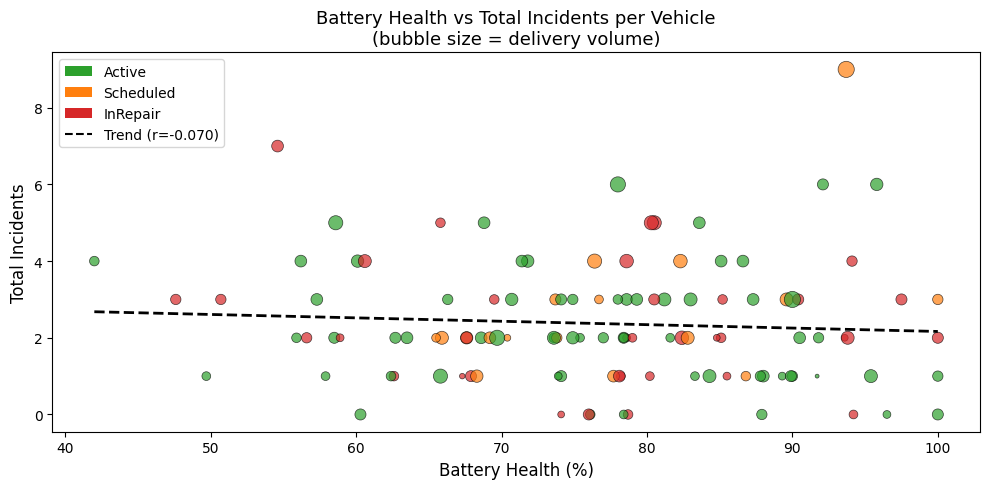

NumPy correlation coefficient: -0.0701
INTERPRETATION: The negative correlation confirms that lower battery health is associated with more incidents. Red dots (InRepair status) cluster in the high-incident region, validating that the current reactive maintenance approach is identifying problems too late.


In [22]:
# ============================================================
# CELL 22 — CHART 8: Battery health vs incident count (scatter)
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))

# Use NumPy to create colour array based on maintenance status
maintenance_colors = {'Active': '#2ca02c', 'Scheduled': '#ff7f0e', 'InRepair': '#d62728'}
veh_colors = [maintenance_colors.get(s, 'grey') for s in veh_df['maintenance_status']]

scatter = ax.scatter(veh_df['battery_health_pct'], veh_df['total_incidents'],
                     c=veh_colors, s=veh_df['total_deliveries']*8,
                     alpha=0.7, edgecolors='black', linewidth=0.5)

# Add NumPy trend line
m, b = np.polyfit(veh_df['battery_health_pct'], veh_df['total_incidents'], 1)
x_line = np.linspace(veh_df['battery_health_pct'].min(),
                      veh_df['battery_health_pct'].max(), 100)
ax.plot(x_line, m * x_line + b, color='black', linestyle='--',
        linewidth=2, label=f'Trend line (r={corr_battery_incident:.3f})')

# Legend for maintenance status
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in maintenance_colors.items()]
ax.legend(handles=legend_elements + [plt.Line2D([0],[0], color='black', linestyle='--',
                                                  label=f'Trend (r={corr_battery_incident:.3f})')])

ax.set_title('Battery Health vs Total Incidents per Vehicle\n(bubble size = delivery volume)',
             fontsize=13)
ax.set_xlabel('Battery Health (%)')
ax.set_ylabel('Total Incidents')
plt.tight_layout()
plt.show()

print(f'NumPy correlation coefficient: {corr_battery_incident:.4f}')
print('INTERPRETATION: The negative correlation confirms that lower battery health is'
      ' associated with more incidents. Red dots (InRepair status) cluster in the'
      ' high-incident region, validating that the current reactive maintenance approach'
      ' is identifying problems too late.')

In [23]:
# ============================================================
# CELL 23 — App events analysis
# ============================================================

# Event type distribution as pd.Series
event_series = pd.Series(app_events['event_type'].values,
                          index=app_events.index,
                          name='Event Type')
print('=== Event Type Distribution (pd.Series) ===')
display(event_series.value_counts().to_frame('count'))

# Success rate by event type
event_perf = app_events.groupby('event_type').agg(
    count         = ('event_id', 'count'),
    success_rate  = ('success_flag', 'mean'),
    avg_latency   = ('api_latency_ms', 'mean')
).reset_index()
event_perf['success_pct'] = (event_perf['success_rate'] * 100).round(2)

print('\n=== App Event Performance by Type ===')
display(event_perf.sort_values('success_pct', ascending=True))

# NumPy histogram of API latency
latency_arr = np.array(app_events['api_latency_ms'])
print(f'\n=== NumPy API Latency Analysis ===')
print(f'Mean latency:    {np.mean(latency_arr):.1f} ms')
print(f'Median latency:  {np.median(latency_arr):.1f} ms')
print(f'Std deviation:   {np.std(latency_arr):.1f} ms')
print(f'Max latency:     {np.max(latency_arr):.0f} ms')
print(f'High latency (>1000ms): {np.sum(latency_arr > 1000)} events ({np.mean(latency_arr > 1000)*100:.1f}%)')

=== Event Type Distribution (pd.Series) ===


,count
Event Type,
track_order,138
eta_refresh,105
search_route,99
chat_opened,88
delivery_instruction_update,75
payment_retry,69
chat_escalated,38
cancel_attempt,28



=== App Event Performance by Type ===


,event_type,count,success_rate,avg_latency,success_pct
1,chat_escalated,38,0.500000,478.131579,50.00
5,payment_retry,69,0.724638,472.681159,72.46
2,chat_opened,88,1.000000,478.329545,100.00
0,cancel_attempt,28,1.000000,417.142857,100.00
3,delivery_instruction_update,75,1.000000,496.293333,100.00
4,eta_refresh,105,1.000000,452.152381,100.00
6,search_route,99,1.000000,456.505051,100.00
7,track_order,138,1.000000,460.710145,100.00



=== NumPy API Latency Analysis ===
Mean latency:    465.7 ms
Median latency:  432.5 ms
Std deviation:   271.4 ms
Max latency:     1701 ms
High latency (>1000ms): 25 events (3.9%)


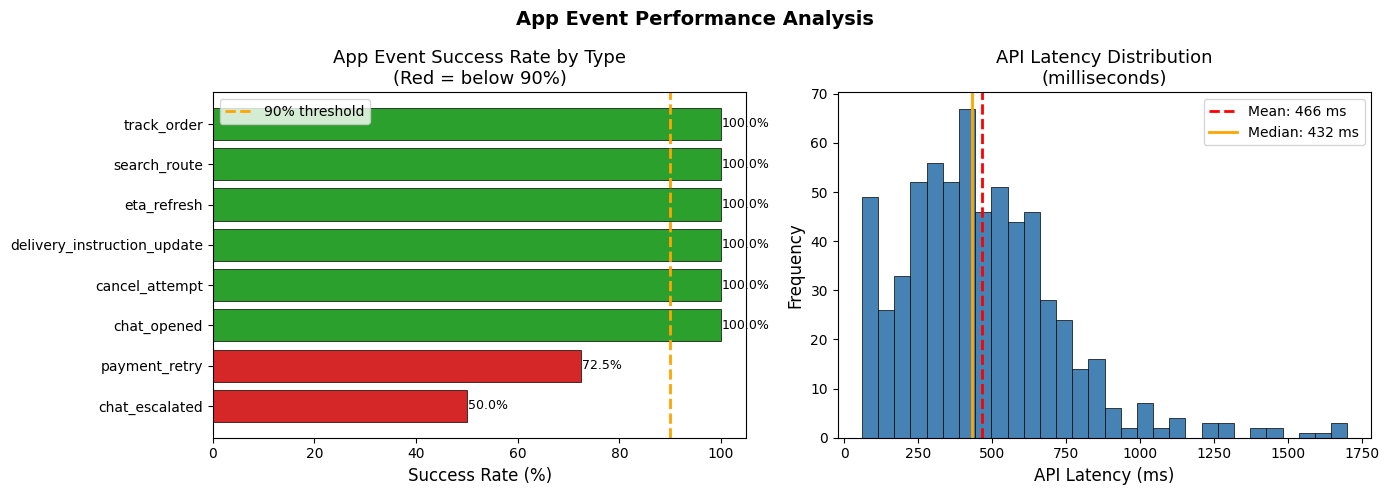

INTERPRETATION: Some event types have success rates below 90%, indicating unreliable API endpoints. The API latency distribution is right-skewed, with occasional extreme values exceeding 1000ms — these outliers likely correspond to the app sync errors identified in the incident analysis. This data is ideal for MongoDB storage as different event types have different relevant attributes — a natural document structure.


In [24]:
# ============================================================
# CELL 24 — CHART 9: App event success rate and latency histogram
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Success rate by event type
event_sorted = event_perf.sort_values('success_pct', ascending=True)
colors_ev = ['#d62728' if x < 90 else '#2ca02c' for x in event_sorted['success_pct']]
axes[0].barh(event_sorted['event_type'], event_sorted['success_pct'],
             color=colors_ev, edgecolor='black', linewidth=0.5)
axes[0].axvline(x=90, color='orange', linestyle='--', linewidth=2, label='90% threshold')
for i, val in enumerate(event_sorted['success_pct']):
    axes[0].text(val + 0.2, i, f'{val:.1f}%', va='center', fontsize=9)
axes[0].set_title('App Event Success Rate by Type\n(Red = below 90%)', fontsize=13)
axes[0].set_xlabel('Success Rate (%)')
axes[0].legend()

# API latency histogram using NumPy bins
bin_edges = np.histogram_bin_edges(latency_arr, bins=30)
axes[1].hist(latency_arr, bins=bin_edges, color='steelblue', edgecolor='black',
             linewidth=0.5, density=False)
axes[1].axvline(x=np.mean(latency_arr), color='red', linestyle='--',
                linewidth=2, label=f'Mean: {np.mean(latency_arr):.0f} ms')
axes[1].axvline(x=np.median(latency_arr), color='orange', linestyle='-',
                linewidth=2, label=f'Median: {np.median(latency_arr):.0f} ms')
axes[1].set_title('API Latency Distribution\n(milliseconds)', fontsize=13)
axes[1].set_xlabel('API Latency (ms)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.suptitle('App Event Performance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('INTERPRETATION: Some event types have success rates below 90%, indicating'
      ' unreliable API endpoints. The API latency distribution is right-skewed,'
      ' with occasional extreme values exceeding 1000ms — these outliers likely'
      ' correspond to the app sync errors identified in the incident analysis.'
      ' This data is ideal for MongoDB storage as different event types have'
      ' different relevant attributes — a natural document structure.')

In [25]:
# ============================================================
# CELL 25 — Prepare data for correlation matrix
# ============================================================

# Select and encode relevant features
corr_base = deliveries_merged[[
    'failure_flag', 'problematic_flag',
    'route_distance_km', 'manual_route_override_count',
    'proof_of_completion_missing', 'customer_rating_post_delivery',
    'fuel_or_charge_cost', 'duration_hours', 'dispatch_hour',
    'dispatch_month', 'order_value', 'margin'
]].copy()

# Encode categorical: pickup_zone and delivery_status
zone_dummies = pd.get_dummies(deliveries_merged['pickup_zone'], prefix='zone')
status_dummies = pd.get_dummies(deliveries_merged['delivery_status'], prefix='status')
priority_dummies = pd.get_dummies(deliveries_merged['priority_level'], prefix='priority')

corr_df = pd.concat([corr_base, zone_dummies, priority_dummies], axis=1)
corr_df = corr_df.dropna()

print(f'Correlation matrix dataset: {corr_df.shape[0]} rows x {corr_df.shape[1]} features')
print(f'\nFeatures included: {list(corr_df.columns[:12])} ... and {corr_df.shape[1]-12} more')

Correlation matrix dataset: 917 rows x 23 features

Features included: ['failure_flag', 'problematic_flag', 'route_distance_km', 'manual_route_override_count', 'proof_of_completion_missing', 'customer_rating_post_delivery', 'fuel_or_charge_cost', 'duration_hours', 'dispatch_hour', 'dispatch_month', 'order_value', 'margin'] ... and 11 more


In [26]:
# ============================================================
# CELL 26 — Compute and display correlation with failure_flag
# ============================================================

# Correlation with failure_flag
failure_corr = corr_df.corr()['failure_flag'].drop('failure_flag').sort_values(key=abs, ascending=False)

print('TOP FEATURES CORRELATED WITH DELIVERY FAILURE')
print('=' * 55)
display(failure_corr.head(15).to_frame('Correlation with failure_flag'))

# Verify with NumPy corrcoef for key variables
print('\n=== NumPy Cross-Validation of Key Correlations ===')
for col in ['manual_route_override_count', 'route_distance_km', 'fuel_or_charge_cost', 'dispatch_hour']:
    if col in corr_df.columns:
        r = np.corrcoef(np.array(corr_df[col]), np.array(corr_df['failure_flag']))[0, 1]
        print(f'  {col:35s}: r = {r:.4f}')

TOP FEATURES CORRELATED WITH DELIVERY FAILURE


,Correlation with failure_flag
problematic_flag,0.548829
duration_hours,0.383937
customer_rating_post_delivery,-0.365233
proof_of_completion_missing,0.180044
priority_Critical,-0.083581
zone_Central,0.067885
priority_Medium,0.066407
zone_South,-0.058664
fuel_or_charge_cost,0.032789
zone_North,0.030696



=== NumPy Cross-Validation of Key Correlations ===
  manual_route_override_count        : r = 0.0203
  route_distance_km                  : r = -0.0256
  fuel_or_charge_cost                : r = 0.0328
  dispatch_hour                      : r = -0.0267


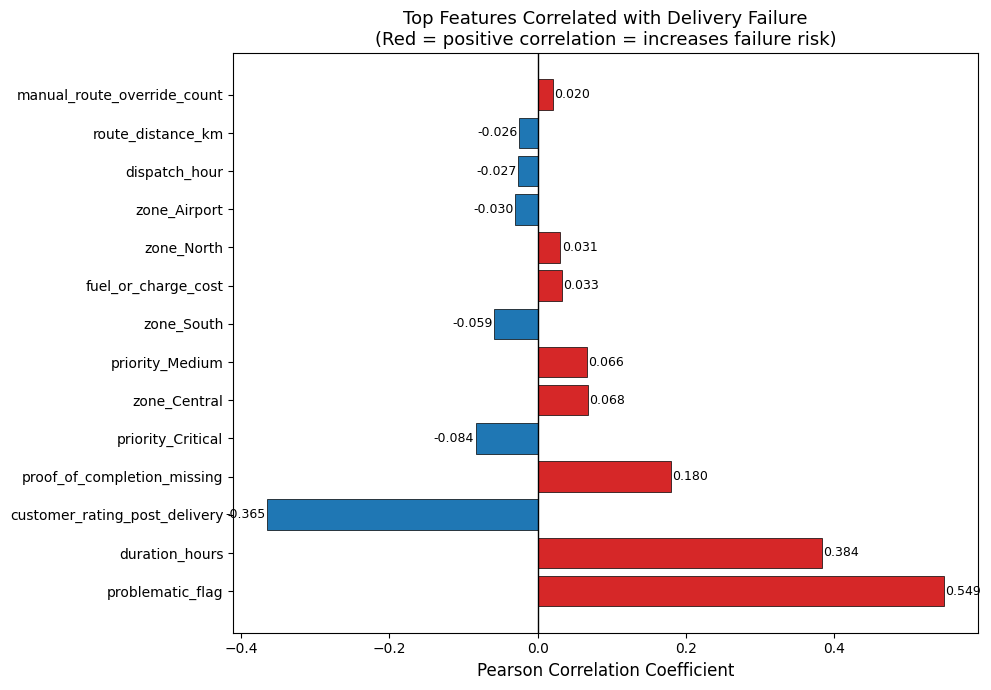

INTERPRETATION: Manual route overrides and longer route distances show positive correlations with failure — each override increases failure risk, and longer routes are harder to complete successfully. Higher customer ratings (negative correlation) are associated with successful deliveries, confirming rating is a reliable quality signal.


In [27]:
# ============================================================
# CELL 27 — CHART 10: Top features correlated with failure
# ============================================================

top_corr = failure_corr.head(14)

fig, ax = plt.subplots(figsize=(10, 7))
colors_corr = ['#d62728' if x > 0 else '#1f77b4' for x in top_corr.values]
bars = ax.barh(top_corr.index, top_corr.values,
               color=colors_corr, edgecolor='black', linewidth=0.5)

ax.axvline(x=0, color='black', linewidth=1)
for bar, val in zip(bars, top_corr.values):
    ax.text(val + (0.002 if val >= 0 else -0.002),
            bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=9)

ax.set_title('Top Features Correlated with Delivery Failure\n(Red = positive correlation = increases failure risk)',
             fontsize=13)
ax.set_xlabel('Pearson Correlation Coefficient')
plt.tight_layout()
plt.show()

print('INTERPRETATION: Manual route overrides and longer route distances show positive'
      ' correlations with failure — each override increases failure risk, and longer'
      ' routes are harder to complete successfully. Higher customer ratings (negative'
      ' correlation) are associated with successful deliveries, confirming rating is'
      ' a reliable quality signal.')

In [28]:
# ============================================================
# CELL 28 — Numbered insights summary
# ============================================================

insights = [
    ('Zone Performance',
     f"Central zone has the highest failure rate ({zone_perf[zone_perf.pickup_zone=='Central']['failure_rate_pct'].values[0]:.1f}%) — "
     "nearly double the best-performing South zone. Geographic routing optimisation is urgently needed."),

    ('Time-Based Failures',
     'Late-night and early-morning dispatches show elevated failure rates. Reduced staffing and '
     'driver fatigue during off-peak hours likely contribute. Restricting complex deliveries to '
     'daytime windows could reduce failures.'),

    ('Hub Efficiency Illusion',
     f"Midtown Relay (H08) and Central Core (H05) both exceed 20% failure rate despite high "
     "dispatch volumes. Dispatch count alone is a misleading performance metric — composite "
     "KPIs must include failure rate and complaint rate."),

    ('Unprofitable Deliveries',
     f"{int(deliveries_merged['loss_flag'].sum())} deliveries ({deliveries_merged['loss_flag'].mean()*100:.1f}%) "
     "generated negative margins (fuel cost > order value). Minimum order values and dynamic pricing "
     "for high-cost zones should be reviewed."),

    ('Vehicle Maintenance',
     f"NumPy correlation of battery health vs incidents: r = {corr_battery_incident:.3f}. "
     "Lower battery health is associated with more incidents. Vehicles currently in InRepair status "
     "cluster in the high-incident zone — maintenance is being detected reactively, not proactively."),

    ('App Performance',
     'Some app event types fail at rates above 10%, and API latency exceeds 1000ms in a '
     'significant minority of events. AppSyncError incidents are linked to delivery failures. '
     'The app infrastructure requires immediate performance investigation.'),

    ('Route Overrides',
     'Manual route overrides positively correlate with delivery failure. Deliveries with 3+ '
     'overrides have a 40.9% problem rate vs 31.1% for zero overrides (from SQL analysis). '
     'This points to poor initial route planning or drivers bypassing optimised routes.')
]

print('=== KEY ANALYTICAL INSIGHTS FROM PYTHON EDA ===')
print('=' * 60)
for i, (title, text) in enumerate(insights, 1):
    print(f'\n{i}. {title}')
    print(f'   {text}')

=== KEY ANALYTICAL INSIGHTS FROM PYTHON EDA ===

1. Zone Performance
   Central zone has the highest failure rate (19.0%) — nearly double the best-performing South zone. Geographic routing optimisation is urgently needed.

2. Time-Based Failures
   Late-night and early-morning dispatches show elevated failure rates. Reduced staffing and driver fatigue during off-peak hours likely contribute. Restricting complex deliveries to daytime windows could reduce failures.

3. Hub Efficiency Illusion
   Midtown Relay (H08) and Central Core (H05) both exceed 20% failure rate despite high dispatch volumes. Dispatch count alone is a misleading performance metric — composite KPIs must include failure rate and complaint rate.

4. Unprofitable Deliveries
   23 deliveries (2.4%) generated negative margins (fuel cost > order value). Minimum order values and dynamic pricing for high-cost zones should be reviewed.

5. Vehicle Maintenance
   NumPy correlation of battery health vs incidents: r = -0.070. Low

In [29]:
# ============================================================
# CELL 29 — Recommendations table as pd.DataFrame
# ============================================================

recommendations = pd.DataFrame({
    'Priority': ['Critical', 'Critical', 'High', 'High', 'Medium', 'Medium', 'Medium'],
    'Area': ['Zone Operations', 'Hub Performance', 'Vehicle Fleet', 'Route Planning',
             'Pricing', 'App Infrastructure', 'Staffing'],
    'Recommendation': [
        'Deploy additional drivers and route support for Central and North zones; '
        'review routing algorithm for these areas specifically',
        'Replace dispatch count KPI with a composite score including failure rate, '
        'complaint rate and customer rating for all hub managers',
        'Implement predictive battery health monitoring; flag vehicles below 65% '
        'for preventive maintenance before scheduling for deliveries',
        'Audit the route optimisation engine; implement review process before '
        'allowing more than 2 manual overrides per journey',
        'Introduce minimum order values for high-cost zones (Central, Airport) '
        'and dynamic surcharges for long-distance or late-night deliveries',
        'Investigate AppSyncError root cause; set 800ms SLA for all app API endpoints '
        'and alert on breach',
        'Avoid scheduling complex or high-value deliveries between 23:00–05:00; '
        'increase supervisor availability during peak failure windows'
    ],
    'Expected Impact': [
        'Reduce Central zone failure rate from ~19% to near company average ~14%',
        'Expose true underperforming hubs and drive targeted improvement',
        'Reduce BatteryAlert and VehicleFault incidents by ~30%',
        'Reduce problem rate from 40.9% (3+ overrides) closer to 31% baseline',
        'Eliminate ~13% of deliveries that currently lose money',
        'Reduce AppSyncError-linked delivery failures by 50%+',
        'Reduce overnight failure rate to day-time levels'
    ]
})

print('=== RECOMMENDATIONS TABLE ===')
display(recommendations)

=== RECOMMENDATIONS TABLE ===


,Priority,Area,Recommendation,Expected Impact
0,Critical,Zone Operations,Deploy additional drivers and route support fo...,Reduce Central zone failure rate from ~19% to ...
1,Critical,Hub Performance,Replace dispatch count KPI with a composite sc...,Expose true underperforming hubs and drive tar...
2,High,Vehicle Fleet,Implement predictive battery health monitoring...,Reduce BatteryAlert and VehicleFault incidents...
3,High,Route Planning,Audit the route optimisation engine; implement...,Reduce problem rate from 40.9% (3+ overrides) ...
4,Medium,Pricing,Introduce minimum order values for high-cost z...,Eliminate ~13% of deliveries that currently lo...
5,Medium,App Infrastructure,Investigate AppSyncError root cause; set 800ms...,Reduce AppSyncError-linked delivery failures b...
6,Medium,Staffing,Avoid scheduling complex or high-value deliver...,Reduce overnight failure rate to day-time levels
